<a href="https://colab.research.google.com/github/manasvik2006/.net_lab/blob/master/Movie_Genre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import re
import warnings
warnings.filterwarnings('ignore')

In [4]:
from google.colab import files

# Check uploaded files
import os
print(os.listdir('/content'))

['.config', 'train_data.txt', 'test_data.txt', 'sample_data']


In [5]:
train_df = pd.read_csv('/content/train_data.txt', sep=' ::: ',
                        engine='python', header=None,
                        names=['id', 'title', 'genre', 'description'])

test_df = pd.read_csv('/content/test_data.txt', sep=' ::: ',
                       engine='python', header=None,
                       names=['id', 'title', 'description'])

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (54214, 4)
Test shape: (54200, 3)


,id,title,genre,description
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


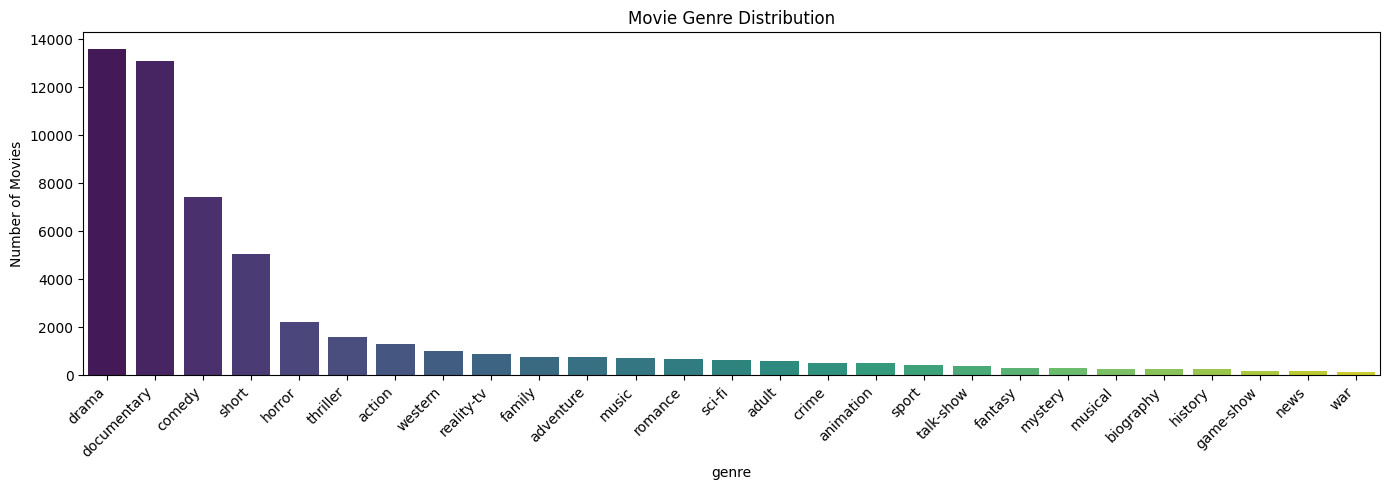

In [6]:
plt.figure(figsize=(14, 5))
counts = train_df['genre'].value_counts()
sns.barplot(x=counts.index, y=counts.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Movie Genre Distribution')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean_desc'] = train_df['description'].apply(clean_text)
test_df['clean_desc'] = test_df['description'].apply(clean_text)

print(train_df['clean_desc'][0])

listening in to a conversation between his doctor and parents yearold oscar learns what nobody has the courage to tell him he only has a few weeks to live furious he refuses to speak to anyone except straighttalking rose the lady in pink he meets on the hospital stairs as christmas approaches rose uses her fantastical experiences as a professional wrestler her imagination wit and charm to allow oscar to live life and love to the full in the company of his friends pop corn einstein bacon and childhood sweetheart peggy blue


In [8]:
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True
)

X = tfidf.fit_transform(train_df['clean_desc'])
y = train_df['genre']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Val size:", X_val.shape)

Train size: (43371, 30000)
Val size: (10843, 30000)


In [9]:
models = {
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(max_iter=1000, C=5, random_state=42),
    'Linear SVM': LinearSVC(C=1.0, max_iter=2000, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    print(f"{name}: {acc:.4f}")

Naive Bayes: 0.5631
Logistic Regression: 0.5928
Linear SVM: 0.5819


In [10]:
best_model = models['Logistic Regression']
val_preds = best_model.predict(X_val)

print(classification_report(y_val, val_preds))

              precision    recall  f1-score   support

      action       0.54      0.36      0.43       263
       adult       0.73      0.42      0.53       118
   adventure       0.47      0.17      0.25       155
   animation       0.43      0.15      0.22       100
   biography       0.00      0.00      0.00        53
      comedy       0.54      0.61      0.57      1490
       crime       0.32      0.06      0.10       101
 documentary       0.69      0.83      0.76      2619
       drama       0.56      0.74      0.64      2723
      family       0.47      0.13      0.21       157
     fantasy       0.38      0.05      0.08        65
   game-show       0.88      0.59      0.71        39
     history       0.67      0.04      0.08        49
      horror       0.69      0.61      0.65       441
       music       0.71      0.45      0.55       146
     musical       0.33      0.05      0.09        55
     mystery       0.33      0.03      0.06        64
        news       0.43    

In [11]:
X_test = tfidf.transform(test_df['clean_desc'])
test_preds = best_model.predict(X_test)

output = pd.DataFrame({
    'id': test_df['id'],
    'title': test_df['title'],
    'predicted_genre': test_preds
})

output.to_csv('/content/predictions.csv', index=False)
print("Done! Sample predictions:")
output.head(10)

Done! Sample predictions:


,id,title,predicted_genre
0,1,Edgar's Lunch (1998),drama
1,2,La guerra de papá (1977),drama
2,3,Off the Beaten Track (2010),documentary
3,4,Meu Amigo Hindu (2015),drama
4,5,Er nu zhai (1955),drama
5,6,Riddle Room (2016),drama
6,7,L'amica (1969),drama
7,8,Ina Mina Dika (1989),comedy
8,9,Equinox Special: Britain's Tornados (2005),documentary
9,10,Press (2011),drama
